<a href="https://colab.research.google.com/github/abeeraz379/Chicago_Crime/blob/main/Chicago_Crime_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  crime dataset for time series analysis
## Original Source: Chicago Data Portal: Crimes 2001 to Present
- Data Description:
All Crimes that were reported in the city of Chicago and their details View Preview
- Includes:
type of crime, exact date/time, lat/long, district/ward, whether there was an arrest, etc.

# load and inspect data

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import glob


In [155]:

zip_path = "/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/04-DataViz/Week14/Data/Chicago_Crime_2001-2022.zip"
extract_path = "/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/04-DataViz/Week14/Data/Chicago_Crime_2001-2022.csv"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")
os.listdir(extract_path)


Extraction complete!


['Data']

In [156]:

csv_files = glob.glob(extract_path + "/Data/*.csv")

print(f"Found {len(csv_files)} CSV files")

df_list = []

for file in csv_files:
    df = pd.read_csv(file)
    df_list.append(df)

# Combine all into one dataframe
chicago_full = pd.concat(df_list, ignore_index=True)

print(" Combined dataset shape:", chicago_full.shape)
chicago_full.head()

Found 22 CSV files
 Combined dataset shape: (7713109, 12)


,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,1326041,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185
1,1319931,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841
2,1324743,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970
3,1310717,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032
4,1318099,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020


# explore data

In [157]:
chicago_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7713109 entries, 0 to 7713108
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Date                  object 
 2   Primary Type          object 
 3   Description           object 
 4   Location Description  object 
 5   Arrest                bool   
 6   Domestic              bool   
 7   Beat                  int64  
 8   District              float64
 9   Ward                  float64
 10  Latitude              float64
 11  Longitude             float64
dtypes: bool(2), float64(4), int64(2), object(4)
memory usage: 603.2+ MB


In [158]:
chicago_full.describe()

,ID,Beat,District,Ward,Latitude,Longitude
count,7.713109e+06,7.713109e+06,7.713062e+06,7.098263e+06,7.624424e+06,7.624424e+06
mean,6.971245e+06,1.186294e+03,1.129533e+01,2.275080e+01,4.184217e+01,-8.767152e+01
std,3.471022e+06,7.030648e+02,6.951157e+00,1.384800e+01,8.881122e-02,6.109191e-02
min,6.340000e+02,1.110000e+02,1.000000e+00,1.000000e+00,3.661945e+01,-9.168657e+01
25%,3.759720e+06,6.210000e+02,6.000000e+00,1.000000e+01,4.176873e+01,-8.771369e+01
50%,6.975839e+06,1.034000e+03,1.000000e+01,2.300000e+01,4.185589e+01,-8.766587e+01
75%,1.003820e+07,1.731000e+03,1.700000e+01,3.400000e+01,4.190677e+01,-8.762820e+01
max,1.319278e+07,2.535000e+03,3.100000e+01,5.000000e+01,4.202291e+01,-8.752453e+01


In [159]:
df.isna().sum()

,0
ID,0
Date,0
Primary Type,0
Description,0
Location Description,847
Arrest,0
Domestic,0
Beat,0
District,0
Ward,10


In [160]:
df.duplicated().sum()

np.int64(0)

In [161]:
for col in df.columns:
    print(col, df[col].nunique())

ID 238858
Date 112244
Primary Type 31
Description 284
Location Description 134
Arrest 2
Domestic 2
Beat 274
District 23
Ward 50
Latitude 117597
Longitude 117583


# preprocessing

In [162]:
chicago_full['Date'] = pd.to_datetime(chicago_full['Date'])
chicago_full = chicago_full.sort_values('Date')
chicago_full.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
1541,3214584,2001-01-01,THEFT,FINANCIAL ID THEFT: OVER $300,STREET,False,False,2221,22.0,21.0,41.732563,-87.669923
1445,1927872,2001-01-01,THEFT,AGG: FINANCIAL ID THEFT,RESIDENCE,False,False,812,8.0,NaN,41.778094,-87.770137
1446,4768442,2001-01-01,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,RESIDENCE,False,False,2124,2.0,4.0,41.807275,-87.593707
1447,2280620,2001-01-01,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,915,9.0,20.0,41.806311,-87.674782
1448,9755214,2001-01-01,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,CHURCH/SYNAGOGUE/PLACE OF WORSHIP,False,False,1022,10.0,24.0,NaN,NaN


In [163]:
chicago_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7713109 entries, 1541 to 7713008
Data columns (total 12 columns):
 #   Column                Dtype         
---  ------                -----         
 0   ID                    int64         
 1   Date                  datetime64[ns]
 2   Primary Type          object        
 3   Description           object        
 4   Location Description  object        
 5   Arrest                bool          
 6   Domestic              bool          
 7   Beat                  int64         
 8   District              float64       
 9   Ward                  float64       
 10  Latitude              float64       
 11  Longitude             float64       
dtypes: bool(2), datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 662.0+ MB


In [164]:
df.isna().sum()

,0
ID,0
Date,0
Primary Type,0
Description,0
Location Description,847
Arrest,0
Domestic,0
Beat,0
District,0
Ward,10


# Topic 1) Comparing Police Districts
- Which district had the most crimes in 2022?
- Which had the least?

In [ ]:
crime_2022 = chicago_full[chicago_full["Date"].dt.year == 2022]


In [ ]:
district_counts = crime_2022["District"].value_counts()

In [ ]:

print("Most crimes district:", district_counts.idxmax())
print("Crimes:", district_counts.max())


Most crimes district: 8.0
Crimes: 14805


In [ ]:
print("Least crimes district:", district_counts.idxmin())
print("Crimes:", district_counts.min())

Least crimes district: 31.0
Crimes: 15


# Topic 2) Crimes Across the Years:

- Is the total number of crimes increasing or decreasing across the years?
- Are there any individual crimes that are doing the opposite (e.g., decreasing when overall crime is increasing or vice-versa)?

In [ ]:
chicago_full["Year"] = chicago_full["Date"].dt.year

In [ ]:

yearly_counts = chicago_full["Year"].value_counts().sort_index()
yearly_counts


,count
Year,
2001,485886
2002,486807
2003,475985
2004,469422
2005,453773
2006,448179
2007,437087
2008,427183
2009,392827


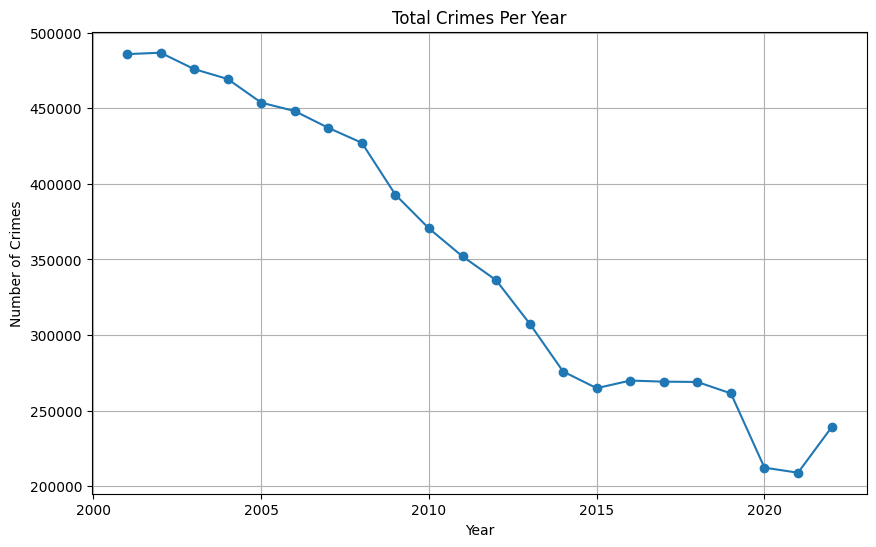

In [ ]:

yearly_counts.plot(kind="line", marker="o", figsize=(10,6))
plt.title("Total Crimes Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.grid()
plt.show()


In [ ]:
crime_types_trend = chicago_full.groupby(["Year", "Primary Type"]).size().unstack(fill_value=0)
crime_types_trend.head()


Primary Type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,...,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,RITUALISM,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
Year,,,,,,,,,,,,,,,,,,,,,
2001,1011,31384,93461,26014,1,1779,55859,29,13241,14949,...,29662,6026,9,2750,8,18441,2239,204,99277,4277
2002,1032,31523,94153,25623,0,1807,55941,27,13880,13732,...,32600,6408,8,2457,2,18523,2173,200,98332,4281
2003,955,29477,88380,25157,0,1571,55011,41,14807,13459,...,31148,6214,6,2430,2,17332,2078,247,98876,4211
2004,778,28850,87136,24564,0,1538,53164,42,15913,13255,...,29532,7476,9,2495,1,15978,1805,215,95463,4298
2005,691,27067,83964,25503,0,1521,54548,37,16655,13590,...,28028,6124,4,2730,2,16047,1817,192,85684,4106


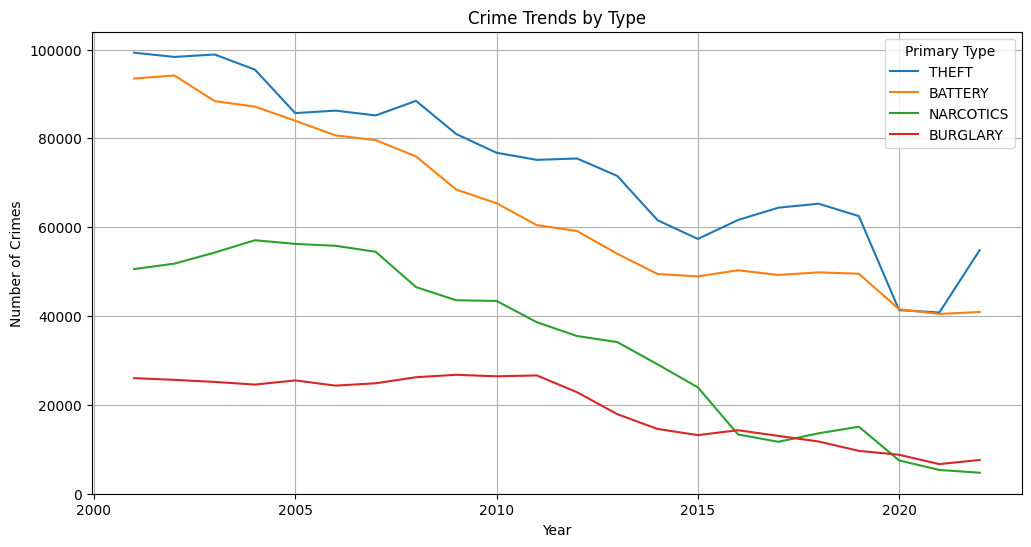

In [ ]:
selected_crimes = ["THEFT", "BATTERY", "NARCOTICS", "BURGLARY"]

crime_types_trend[selected_crimes].plot(figsize=(12,6))
plt.title("Crime Trends by Type")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.grid()
plt.show()

# Topic 3) Comparing AM vs. PM Rush Hour:
- Are crimes more common during AM rush hour or PM rush hour?
You can consider any crime that occurred between 7 AM - 10 AM as AM rush hour
You can consider any crime that occurred between 4 - 7 PM as PM rush hour.
- Answer the question: What are the top 5 most common crimes during AM rush hour? What are the top 5 most common crimes during PM rush hour?
- Answer the question: Are Motor Vehicle Thefts more common during AM rush hour or PM Rush Hour?

In [ ]:
chicago_full["Hour"] = chicago_full["Date"].dt.hour

In [ ]:
am_rush = chicago_full[(chicago_full["Hour"] >= 7) & (chicago_full["Hour"] < 10)]
pm_rush = chicago_full[(chicago_full["Hour"] >= 16) & (chicago_full["Hour"] < 19)]

In [ ]:
print("AM rush crimes:", len(am_rush))
print("PM rush crimes:", len(pm_rush))

AM rush crimes: 770651
PM rush crimes: 1206353


In [ ]:
top5_am = am_rush["Primary Type"].value_counts().head(5)
print("Top 5 AM crimes:\n", top5_am)
top5_pm = pm_rush["Primary Type"].value_counts().head(5)
print("Top 5 PM crimes:\n", top5_pm)

Top 5 AM crimes:
 Primary Type
THEFT              185239
BATTERY            108199
CRIMINAL DAMAGE     81281
BURGLARY            73999
OTHER OFFENSE       62453
Name: count, dtype: int64
Top 5 PM crimes:
 Primary Type
THEFT              293514
BATTERY            213002
CRIMINAL DAMAGE    134101
NARCOTICS          103032
ASSAULT             89600
Name: count, dtype: int64


In [ ]:
mv_theft_am = am_rush[am_rush["Primary Type"] == "MOTOR VEHICLE THEFT"]
mv_theft_pm = pm_rush[pm_rush["Primary Type"] == "MOTOR VEHICLE THEFT"]

print("AM Motor Vehicle Theft:", len(mv_theft_am))
print("PM Motor Vehicle Theft:", len(mv_theft_pm))

AM Motor Vehicle Theft: 41578
PM Motor Vehicle Theft: 53716


# Topic 4) Comparing Months:
- Answer the question: What months have the most crime? What months have the least?
- Answer the question: Are there any individual crimes that do not follow this pattern? If so, which crimes?

In [ ]:
chicago_full["Month"] = chicago_full["Date"].dt.month

In [ ]:
monthly_counts = chicago_full["Month"].value_counts().sort_index()
monthly_counts

,count
Month,
1,601236
2,529391
3,629704
4,627175
5,682932
6,681739
7,717232
8,710444
9,668242


In [ ]:
most_month = monthly_counts.idxmax()
least_month = monthly_counts.idxmin()

print("Month with most crimes:", most_month)
print("Crimes:", monthly_counts.max())

print("Month with least crimes:", least_month)
print("Crimes:", monthly_counts.min())

Month with most crimes: 7
Crimes: 717232
Month with least crimes: 2
Crimes: 529391


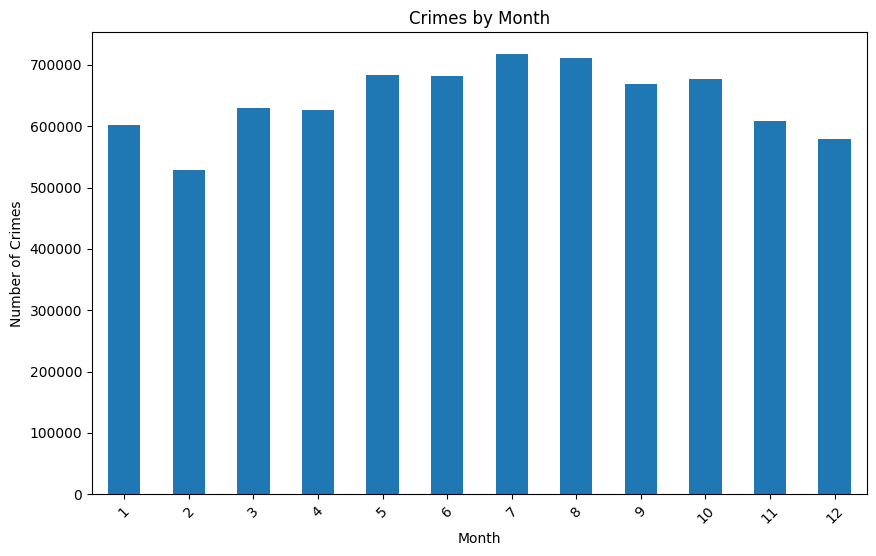

In [ ]:

monthly_counts.plot(kind="bar", figsize=(10,6))
plt.title("Crimes by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.show()


In [ ]:
crime_month_trend = chicago_full.groupby(["Month", "Primary Type"]).size().unstack(fill_value=0)


In [ ]:

crime_trend_change = crime_month_trend.diff().mean()

print(crime_trend_change.sort_values(ascending=False).head())
print(crime_trend_change.sort_values().head())

Primary Type
THEFT                  290.000000
BURGLARY               272.363636
ROBBERY                212.454545
MOTOR VEHICLE THEFT    161.000000
CRIMINAL DAMAGE         50.545455
dtype: float64
Primary Type
NARCOTICS           -1092.363636
OTHER OFFENSE        -641.090909
BATTERY              -267.090909
CRIMINAL TRESPASS    -242.454545
PROSTITUTION         -184.636364
dtype: float64


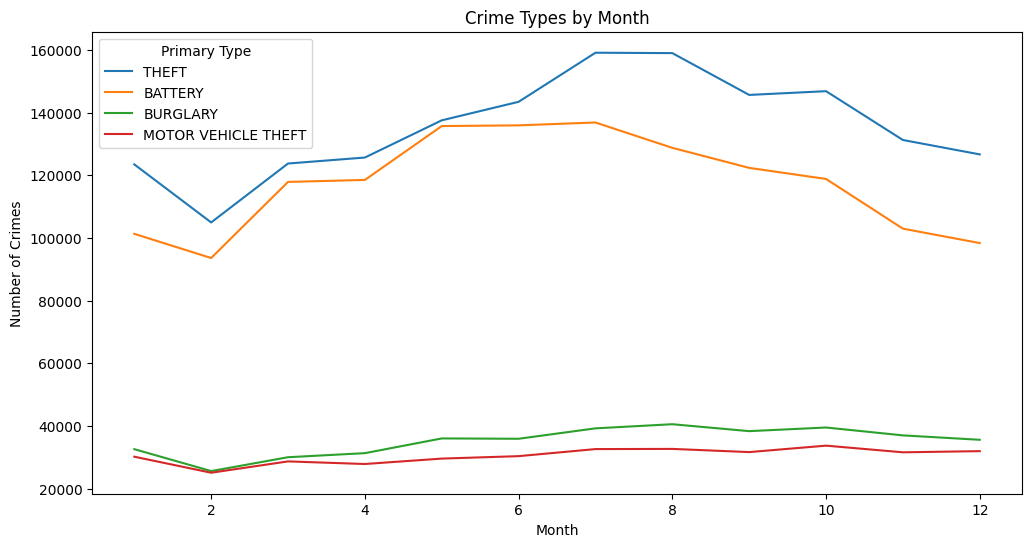

In [ ]:
selected = ["THEFT", "BATTERY", "BURGLARY", "MOTOR VEHICLE THEFT"]

crime_month_trend[selected].plot(figsize=(12,6))
plt.title("Crime Types by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.show()

# Topic 5) Comparing Holidays:
- Answer the question: What are the top 3 holidays with the largest number of crimes?
- Answer the question:  For each of the top 3 holidays with the most crime, what are the top 5 most common crimes on that holiday?

In [ ]:
!pip install holidays

In [ ]:
import holidays
from holidays import country_holidays

In [ ]:
chicago_full["Day"] = chicago_full["Date"].dt.day

In [ ]:
us_holidays = country_holidays('US')
us_holidays

holidays.country_holidays('US')

In [ ]:
chicago_full["US Holiday"] = [us_holidays.get(day) for day in chicago_full['Date']]

In [ ]:

top3_holidays = chicago_full["US Holiday"].head(3)
print(top3_holidays)


1541    New Year's Day
1445    New Year's Day
1446    New Year's Day
Name: US Holiday, dtype: object


In [ ]:
holiday_data = chicago_full[chicago_full["US Holiday"].notna()]

top3_holidays = holiday_data["US Holiday"].value_counts().head(3)

print("Top 3 holidays:\n", top3_holidays)


for holiday in top3_holidays.index:
    print(f"\nTop crimes on {holiday}:")

    top_crimes = (
        holiday_data[holiday_data["US Holiday"] == holiday]["Primary Type"]
        .value_counts()
        .head(5)
    )

    print(top_crimes)

Top 3 holidays:
 US Holiday
New Year's Day      32725
Independence Day    22672
Labor Day           22164
Name: count, dtype: int64

Top crimes on New Year's Day:
Primary Type
THEFT                         6845
BATTERY                       6043
CRIMINAL DAMAGE               3236
DECEPTIVE PRACTICE            2934
OFFENSE INVOLVING CHILDREN    2380
Name: count, dtype: int64

Top crimes on Independence Day:
Primary Type
BATTERY            5805
THEFT              4074
CRIMINAL DAMAGE    3309
ASSAULT            1547
NARCOTICS          1522
Name: count, dtype: int64

Top crimes on Labor Day:
Primary Type
BATTERY            4607
THEFT              4520
CRIMINAL DAMAGE    2475
NARCOTICS          2078
ASSAULT            1525
Name: count, dtype: int64


# Topic 6) What cycles (seasonality) can you find in this data?
- Make sure to select the data of interest and resample it to the frequency you want. (For suggestions, See the "Suggested data to check for seasons" list at the bottom of this topic.)
Use statsmodels.tsa.seasonal.seasonal_decompose() to decompose the time series.
- Note: seasonal_decompose cannot read data resampled as minutes or smaller, and if you try seconds, you will crash your computer. Keep your resampling at hours or more.

- Show and describe each cycle you can find.
(Hint: If your seasonal results are too dense to read, try zooming in to look at just one year or one month and try different levels of resampling).
- Answer the question: How long is a cycle?
- Answer the question: What is the magnitude of the cycle? (Compare min and max).

In [ ]:
chicago_full = chicago_full.set_index("Date")
daily_crimes = chicago_full.resample("D").size()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(daily_crimes, model="additive", period=365)


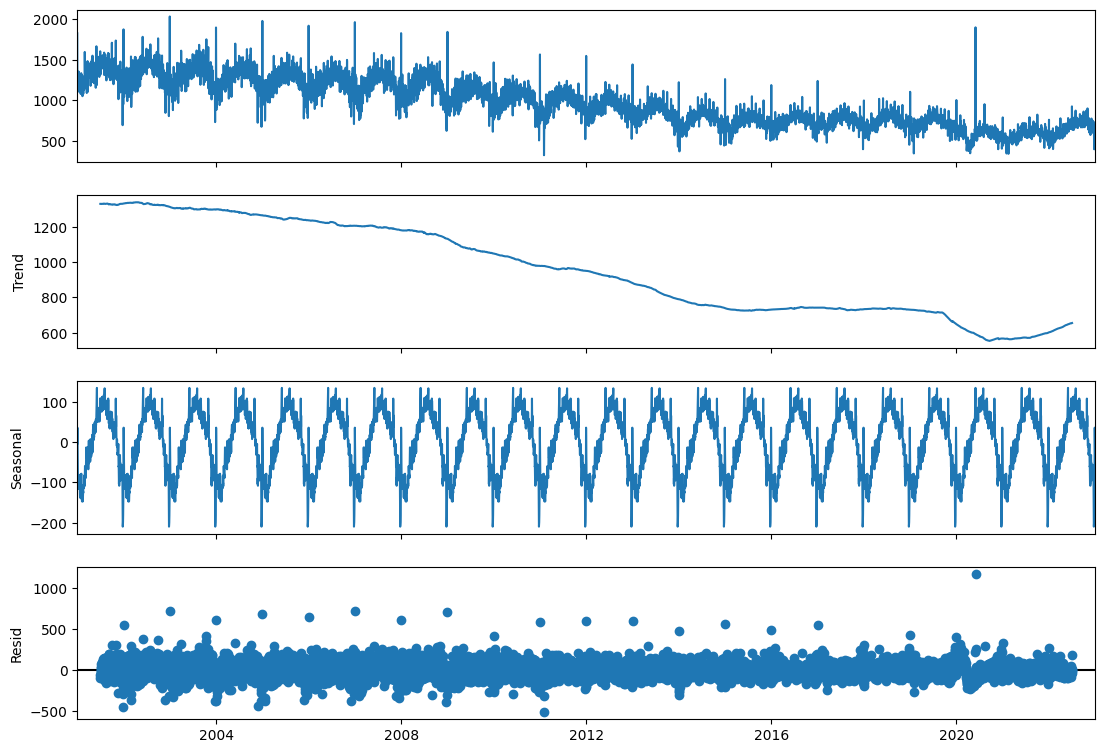

In [ ]:

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()


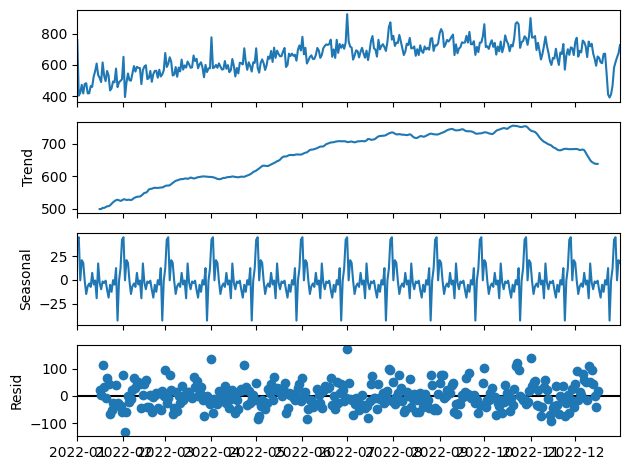

In [ ]:

one_year = daily_crimes["2022"]

decomposition_zoom = seasonal_decompose(one_year, model="additive", period=30)

decomposition_zoom.plot()
plt.show()


# crime count forecast

# (Theft)

## imports

In [165]:
!pip install pmdarima

In [166]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

import statsmodels.tsa.api as tsa
from pmdarima.model_selection import train_test_split
from pmdarima.arima.utils import ndiffs, nsdiffs

# Set wide fig size for plots
plt.rcParams['figure.figsize']=(12,3)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

sns.set_style("whitegrid")

## load data

In [167]:
# Transform the data to obtain a time series of the crime count per month using .size()
chicago_full['Date'] = pd.to_datetime(chicago_full['Date'])
chicago_full = chicago_full.set_index('Date').sort_index()

theft_monthly = chicago_full[chicago_full['Primary Type'] == 'THEFT'].resample('M').size()

/tmp/ipykernel_7433/178567879.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  theft_monthly = chicago_full[chicago_full['Primary Type'] == 'THEFT'].resample('M').size()


In [168]:
#Check for and address null values
theft_monthly.isna().sum()

np.int64(0)

In [169]:
len(theft_monthly)

264

## Custom Functions

In [170]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10,4), title='Comparing Forecast vs. True Data'):
    ### PLot training data, and forecast (with upper/,lower ci)
    fig, ax = plt.subplots(figsize=figsize)

    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training  and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)

    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")

    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                   forecast_df['mean_ci_upper'],
                   color='green', alpha=0.3,  lw=2)

    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax

In [171]:
# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
    icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        "# of Lags Used":nlags,
                       '# of Observations':nobs,
                        'p-value': round(pval,6),
                        'alpha': alpha,
                       'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index =[label])

In [172]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True, output_dict=False,):
    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = np.sqrt(mse)
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100

    if verbose == True:
        # Print Result with label
        header = "---" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")

    if output_dict == True:
        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }
        return metrics

In [173]:
def get_sig_lags(ts, type='ACF',  nlags=None,alpha=0.5):


    if type == 'ACF':
        # Running the function used by plot_acf
        corr_values, conf_int = tsa.stattools.acf(ts, alpha=alpha, nlags=nlags)

    elif type=='PACF':
        corr_values, conf_int = tsa.stattools.pacf(ts, alpha=alpha, nlags=nlags)

    else:
        raise Exception("type must be either 'ACF' or 'PACF'")

    # Determine lags
    lags =range(len(corr_values))

    # Create a centered version of the acf_df
    corr_df = pd.DataFrame({type:corr_values,
                            'Lags':lags,
                            'lower ci': conf_int[:,0]-corr_values, # subtract acf from lower ci to center
                            'upper ci': conf_int[:,1]-corr_values, # subtact acf to upper ci to center
                                 })
    corr_df = corr_df.set_index("Lags")

    # Getting filter for sig lags
    filter_sig_lags = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])

    # Get lag #'s
    sig_lags= corr_df.index[filter_sig_lags]
    sig_lags = sig_lags[sig_lags!=0]

    return sig_lags

In [174]:
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                 acf_kws={}, pacf_kws={},
                  annotate_seas=False, m = None,
                 seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)


    # Sig lags line style
    sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')

    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag,label='sig', **sig_vline_kwargs )

    # PACF
    tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)




    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")

        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m

        # Seasonal Lines style
        seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")

    fig.tight_layout()

    return fig

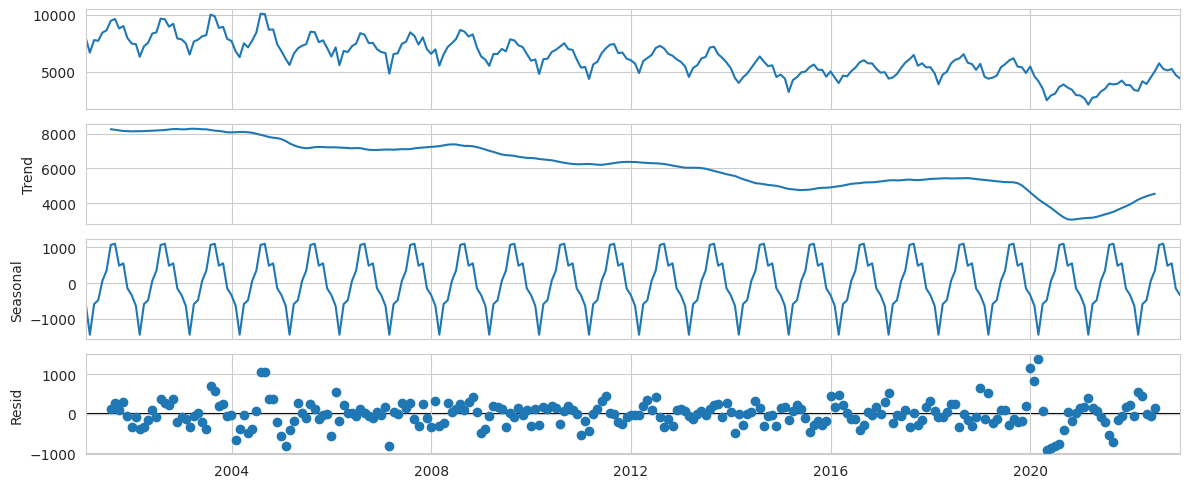

In [175]:
#Decompose the Time series to detect seasonality and decide whether to use a seasonal model or not
decomp = tsa.seasonal_decompose(theft_monthly)
fig = decomp.plot()
fig.set_size_inches(12,5)
fig.tight_layout()

## detect seasonality

In [176]:
# Determine if nonseasonal and/or seasonal differencing is required
get_adfuller_results(theft_monthly)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-1.393935,13,250,0.58518,0.05,False


In [177]:
# determine d
d = ndiffs(theft_monthly)
print (f'd = {d}')
# determine D
D = nsdiffs(theft_monthly, m = 12)
print (f'D = {D}')

d = 1
D = 0


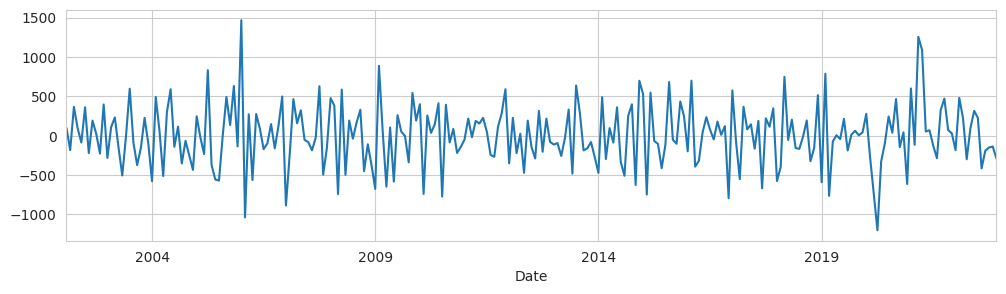

In [178]:
# apply both differencings
ts_diff = theft_monthly.diff().diff(12).dropna()
ts_diff.plot();

## ACF and PACF

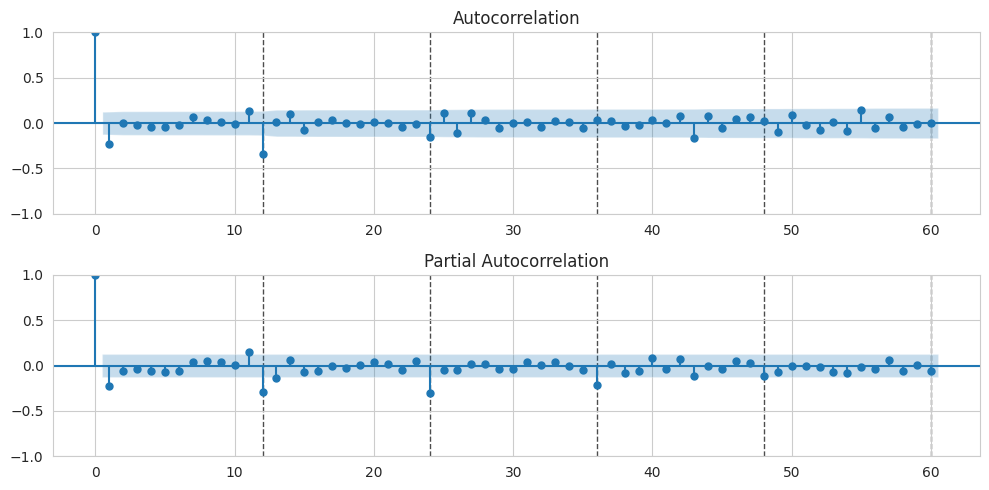

In [179]:
# Use the ACF and PACF plots of stationarity data to estimate initial orders
plot_acf_pacf(ts_diff, annotate_seas = True, m = 12, nlags = 60);

## Split the time series

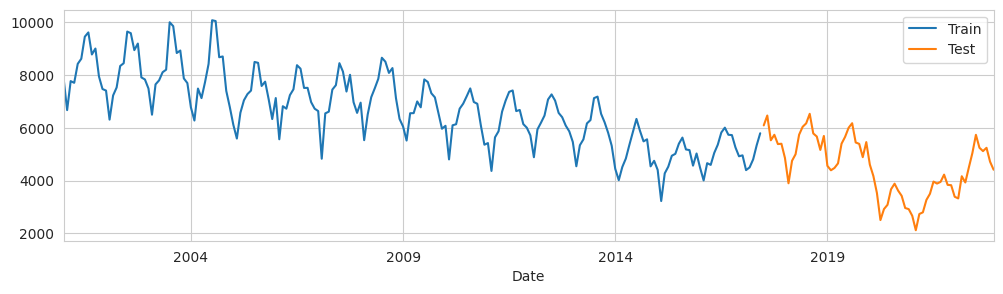

In [180]:
# Split the time series into training and test data (Remember we want to predict 6 months)
# tts
train, test = train_test_split(theft_monthly, test_size=.25)
ax = train.plot(label='Train')
test.plot(ax=ax, label='Test')
ax.legend();


## ARIMA/SARIMA model

In [181]:
# Fit a manual ARIMA/SARIMA model based on the orders determined during your exploration.
# Make forecasts with your model.
# Orders for non seasonal components
p = 1  # nonseasonal AR
d = 1  # nonseasonal differencing
q = 0  # nonseasonal MA

# Orders for seasonal components
P = 1  # Seasonal AR
D = 0  # Seasonal differencing
Q = 1  # Seasonal MA
m = 12 # Seasonal period

sarima = tsa.ARIMA(train, order = (p,d,q), seasonal_order=(P,D,Q,m)).fit()

# Obtain summary
sarima.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  198
Model:             ARIMA(1, 1, 0)x(1, 0, [1], 12)   Log Likelihood               -1425.999
Date:                            Mon, 29 Jun 2026   AIC                           2859.998
Time:                                    17:25:29   BIC                           2873.130
Sample:                                01-31-2001   HQIC                          2865.314
                                     - 06-30-2017                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2981      0.066     -4.512      0.000      -0.428      -0.169
ar.S.L12       0.9771      0.009    104.699      0.000       0.959       0.995
ma.S.L12      -0.6601      0.058    -11.299      0.000      -0.775      -0.546
sigma2      9.373e+04   8805.250     10.645      0.000    7.65e+04    1.11e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                 3.53
Prob(Q):                              0.79   Prob(JB):                         0.17
Heteroskedasticity (H):               0.48   Skew:                            -0.09
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.63
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

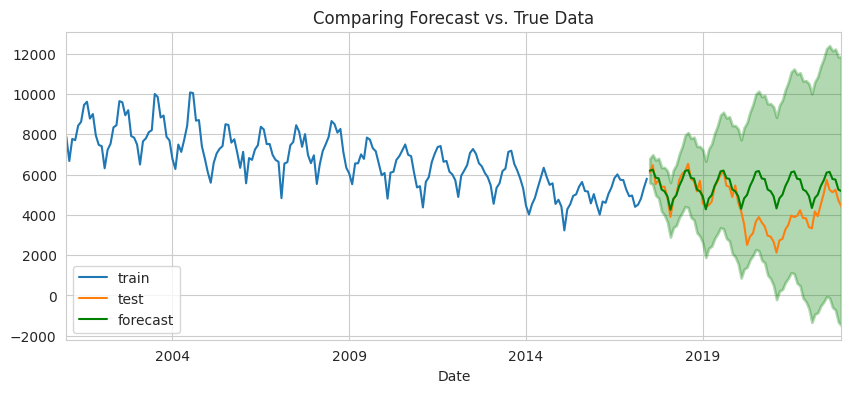

In [182]:
# Plot the forecasts versus the test data
forecast_df = sarima.get_forecast(steps=len(test)).summary_frame()
plot_forecast(train, test, forecast_df);


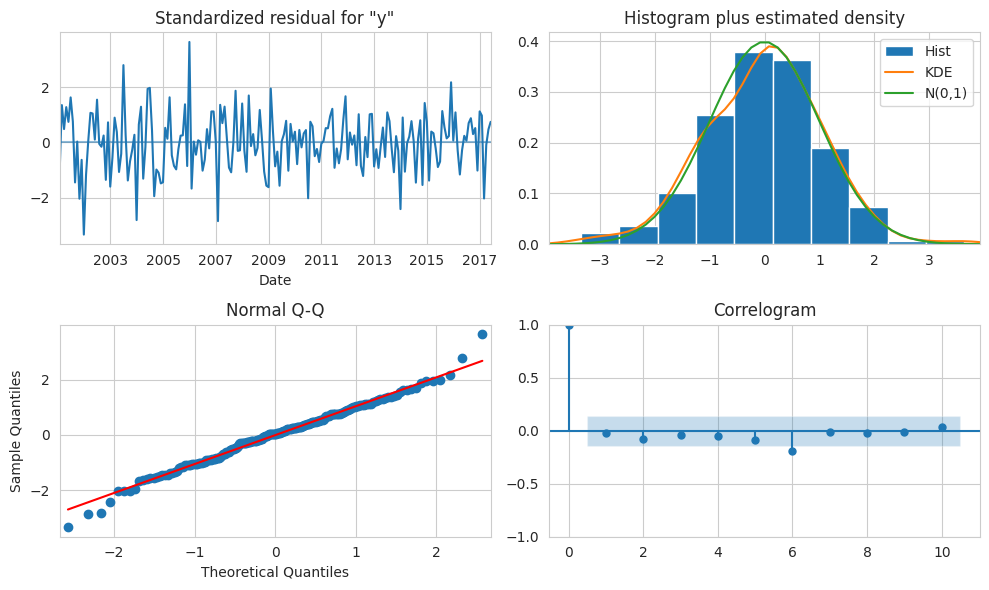

In [183]:
# Obtain diagnostic plots
fig = sarima.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 946.087
- MSE = 1,689,168.878
- RMSE = 1,299.680
- R^2 = -0.391
- MAPE = 27.37%


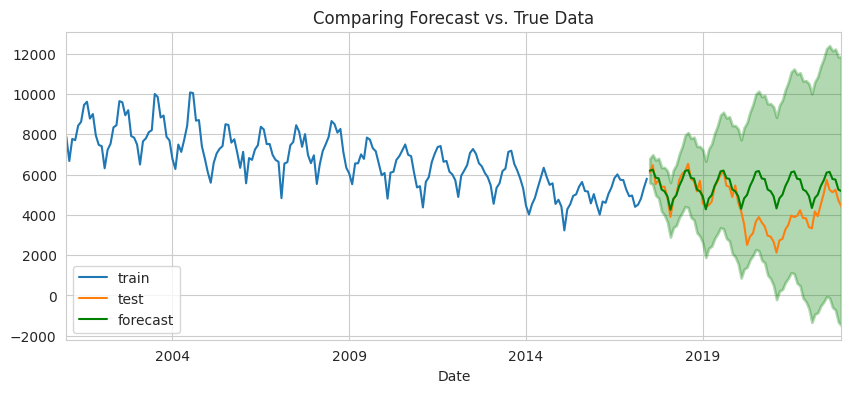

In [184]:
# Obtain metrics for evaluation
forecast_df = sarima.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

## Tune with pmdarima's auto_arima
- Fit a model on training data with the best parameters from auto_arima
- Obtain metrics for evaluation
- Make forecasts with the auto_arima model
- Plot the forecasts versus the test data

In [185]:
# Default auto_arima will select model based on AIC score
import pmdarima as pm
auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=4.49 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3128.037, Time=0.12 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2897.254, Time=3.54 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3017.305, Time=2.02 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3126.088, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=3128.164, Time=0.16 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=inf, Time=4.86 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=2861.575, Time=3.43 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=3016.289, Time=1.27 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=7.62 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=2861.049, Time=2.06 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=2971.384, Time=1.30 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=4.28 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=2878.462, Time=4.36 sec
 ARIMA(2,1,0)(1,0,2)[12] intercept   : 

In [186]:
# the auto_arima will store our best nonseasonal and seasonal orders separtely
print(auto_model.order)
print(auto_model.seasonal_order)

(2, 1, 0)
(1, 0, 2, 12)


In [187]:
# Obtain summary of the best model from auto_arima
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                       y   No. Observations:                  198
Model:             SARIMAX(2, 1, 0)x(1, 0, [1, 2], 12)   Log Likelihood               -1423.320
Date:                                 Mon, 29 Jun 2026   AIC                           2860.641
Time:                                         17:26:52   BIC                           2883.623
Sample:                                     01-31-2001   HQIC                          2869.944
                                          - 06-30-2017                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.3172      1.897     -0.694      0.487      -5.035       2.400
ar.L1         -0.3330      0.070     -4.787      0.000      -0.469      -0.197
ar.L2         -0.1078      0.066     -1.637      0.102      -0.237       0.021
ar.S.L12       0.9845      0.008    116.127      0.000       0.968       1.001
ma.S.L12      -0.5770      0.078     -7.403      0.000      -0.730      -0.424
ma.S.L24      -0.1321      0.087     -1.513      0.130      -0.303       0.039
sigma2       9.03e+04   8744.744     10.326      0.000    7.32e+04    1.07e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 3.51
Prob(Q):                              0.96   Prob(JB):                         0.17
Heteroskedasticity (H):               0.50   Skew:                            -0.04
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.65
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 734.986
- MSE = 1,131,528.896
- RMSE = 1,063.733
- R^2 = 0.068
- MAPE = 21.03%


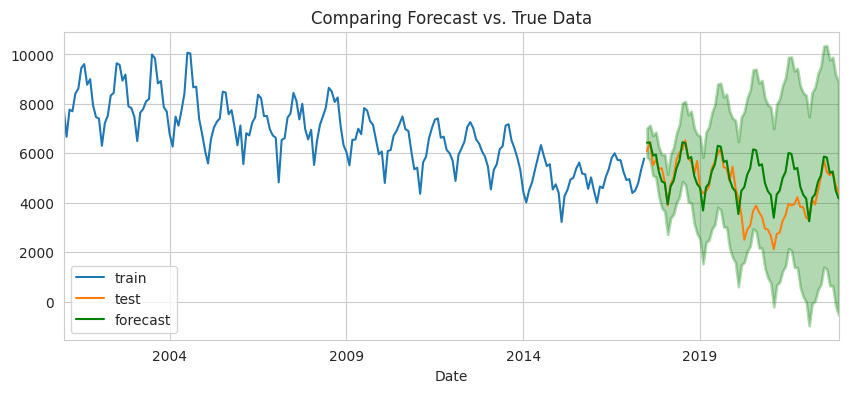

In [188]:
# Use auto_arima parameters to fit an ARIMA
auto_model = tsa.ARIMA(
    train, order=auto_model.order, seasonal_order=auto_model.seasonal_order
).fit()


# Obtain forecast as a dataframe with confidence intervals
forecast_df = auto_model.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

In [189]:
def forecast_change(forecast):
    first = forecast.iloc[0]
    last = forecast.iloc[-1]
    net_change = last - first
    pct_change = (net_change / first) * 100
    return first, last, net_change, pct_change
first, last, net, pct = forecast_change(forecast_df)
print(first, last, net, pct)

y
mean             6433.136755
mean_se           299.319473
mean_ci_lower    5846.481367
mean_ci_upper    7019.792142
Name: 2017-07-31 00:00:00, dtype: float64 y
mean             4178.246549
mean_se          2405.615463
mean_ci_lower    -536.673119
mean_ci_upper    8893.166217
Name: 2022-12-31 00:00:00, dtype: float64 y
mean            -2254.890206
mean_se          2106.295990
mean_ci_lower   -6383.154486
mean_ci_upper    1873.374075
dtype: float64 y
mean             -35.051178
mean_se          703.694941
mean_ci_lower   -109.179421
mean_ci_upper     26.687031
dtype: float64


# Results for Theft

Model:		ARIMA(1, 1, 0)x(1, 0, [1], 12)
- Regression Metrics:
- MAE = 946.087
- MSE = 1,689,168.878
- RMSE = 1,299.680
- R^2 = -0.391
- MAPE = 27.37%
------------------------------------------------------------
Model:	SARIMAX(2, 1, 0)x(1, 0, [1, 2], 12)
-Regression Metrics:
- MAE = 734.986
- MSE = 1,131,528.896
- RMSE = 1,063.733
- R^2 = 0.068
- MAPE = 21.03%

**according to these results the SARIMAX(2, 1, 0)x(1, 0, [1, 2], 12) model is better**

# (Total Crime)

## load data

In [190]:
# Transform the data to obtain a time series of the crime count per month using .size()
Total_monthly = chicago_full.resample('M').size()

/tmp/ipykernel_7433/1421174233.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Total_monthly = chicago_full.resample('M').size()


In [191]:
#Check for and address null values
Total_monthly.isna().sum()

np.int64(0)

## detect seasonality

In [192]:
# Determine if nonseasonal and/or seasonal differencing is required
get_adfuller_results(Total_monthly)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-1.325784,15,248,0.617295,0.05,False


In [193]:
# determine d
d = ndiffs(Total_monthly)
print (f'd = {d}')
# determine D
D = nsdiffs(Total_monthly, m = 12)
print (f'D = {D}')

d = 1
D = 0


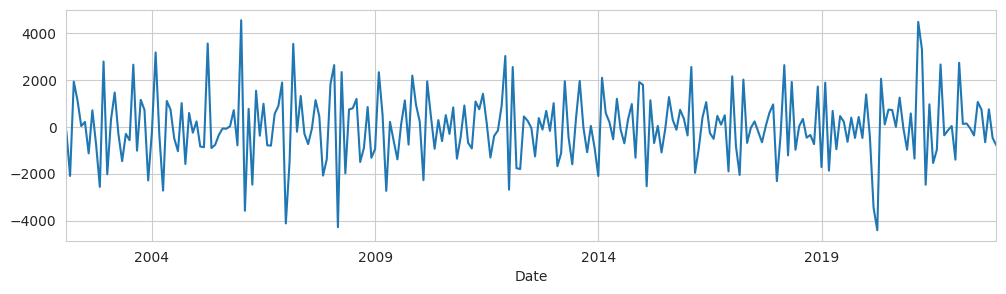

In [194]:
# apply both differencings
ts_diff = Total_monthly.diff().diff(12).dropna()
ts_diff.plot();

## ACF and PACF

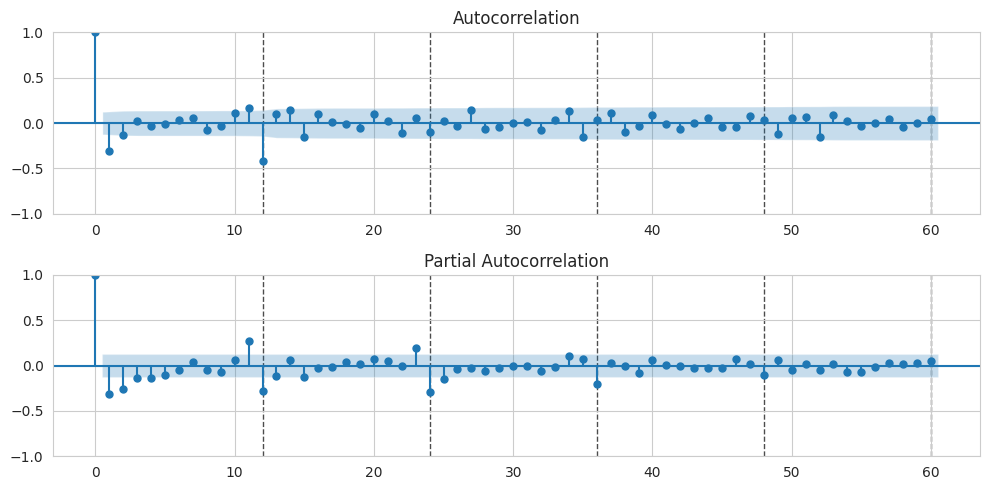

In [195]:
# Use the ACF and PACF plots of stationarity data to estimate initial orders
plot_acf_pacf(ts_diff, annotate_seas = True, m = 12, nlags = 60);

## Split the time series

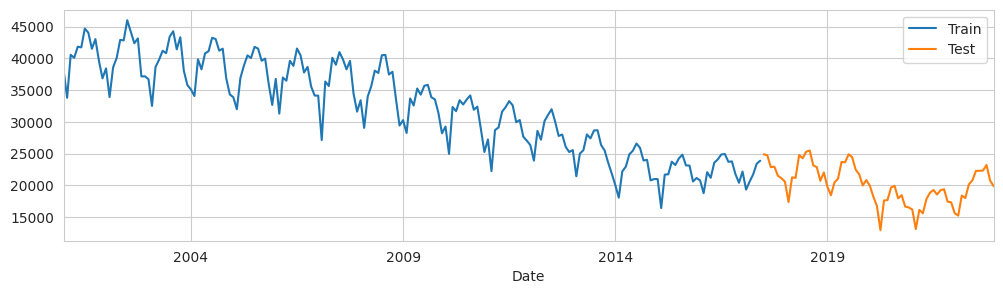

In [196]:
# Split the time series into training and test data (Remember we want to predict 6 months)
# tts
train, test = train_test_split(Total_monthly, test_size=.25)
ax = train.plot(label='Train')
test.plot(ax=ax, label='Test')
ax.legend();


## ARIMA/SARIMA model

In [197]:
# Fit a manual ARIMA/SARIMA model based on the orders determined during your exploration.
# Make forecasts with your model.
# Orders for non seasonal components
p = 1  # nonseasonal AR
d = 1  # nonseasonal differencing
q = 0  # nonseasonal MA

# Orders for seasonal components
P = 1  # Seasonal AR
D = 0  # Seasonal differencing
Q = 1  # Seasonal MA
m = 12 # Seasonal period

sarima = tsa.ARIMA(train, order = (p,d,q), seasonal_order=(P,D,Q,m)).fit()

# Obtain summary
sarima.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  198
Model:             ARIMA(1, 1, 0)x(1, 0, [1], 12)   Log Likelihood               -1741.671
Date:                            Mon, 29 Jun 2026   AIC                           3491.342
Time:                                    17:26:59   BIC                           3504.475
Sample:                                01-31-2001   HQIC                          3496.658
                                     - 06-30-2017                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1671      0.041     -4.098      0.000      -0.247      -0.087
ar.S.L12       0.9426      0.016     57.307      0.000       0.910       0.975
ma.S.L12      -0.7815      0.034    -22.917      0.000      -0.848      -0.715
sigma2      2.294e+06   1.29e-09   1.78e+15      0.000    2.29e+06    2.29e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.80   Jarque-Bera (JB):                94.44
Prob(Q):                              0.37   Prob(JB):                         0.00
Heteroskedasticity (H):               0.16   Skew:                            -0.73
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.18e+30. Standard errors may be unstable.
"""

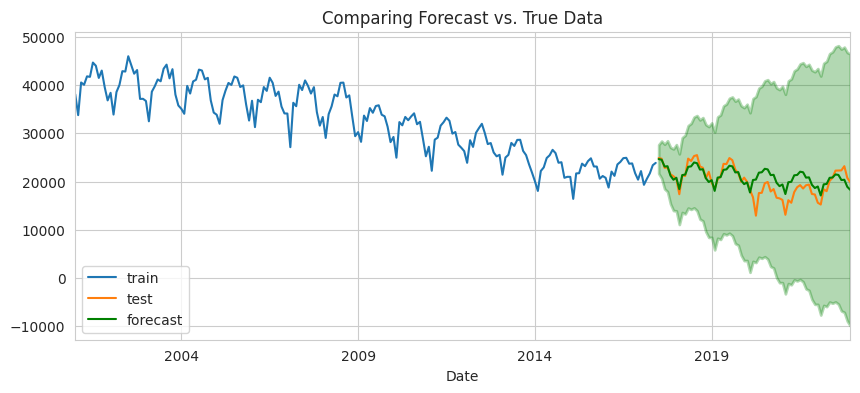

In [198]:
# Plot the forecasts versus the test data
forecast_df = sarima.get_forecast(steps=len(test)).summary_frame()
plot_forecast(train, test, forecast_df);


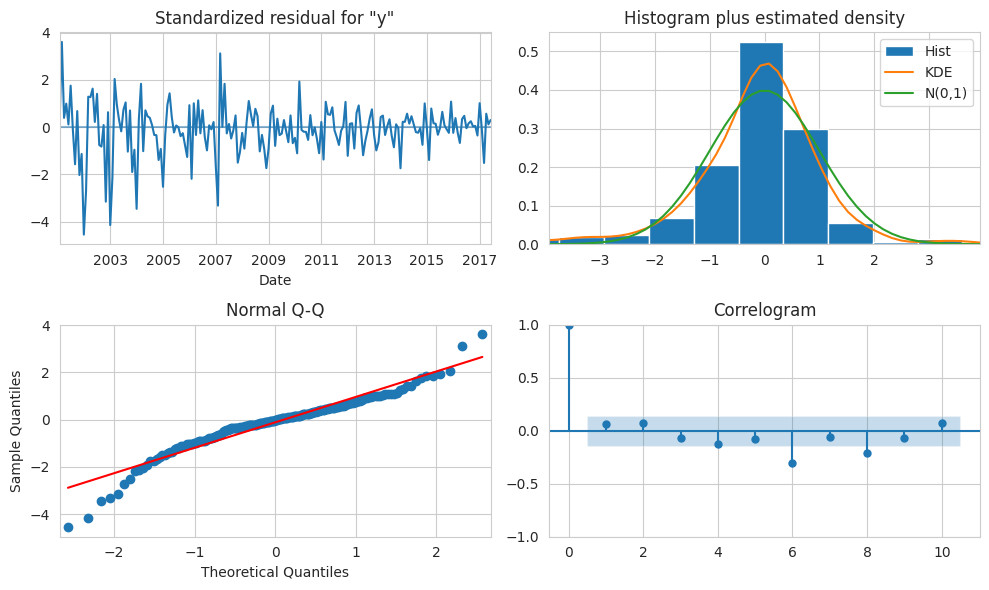

In [199]:
# Obtain diagnostic plots
fig = sarima.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 1,694.991
- MSE = 5,012,026.422
- RMSE = 2,238.756
- R^2 = 0.432
- MAPE = 9.45%


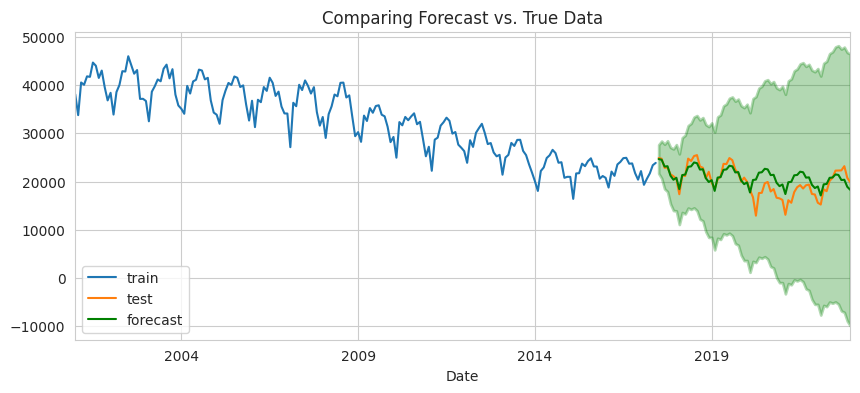

In [200]:
# Obtain metrics for evaluation
forecast_df = sarima.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

In [201]:
def forecast_change(forecast):
    first = forecast.iloc[0]
    last = forecast.iloc[-1]
    net_change = last - first
    pct_change = (net_change / first) * 100
    return first, last, net_change, pct_change
first, last, net, pct = forecast_change(forecast_df)
print(first, last, net, pct)

y
mean             24666.102276
mean_se           1514.557377
mean_ci_lower    21697.624363
mean_ci_upper    27634.580188
Name: 2017-07-31 00:00:00, dtype: float64 y
mean             18286.978050
mean_se          14393.228101
mean_ci_lower    -9923.230650
mean_ci_upper    46497.186749
Name: 2022-12-31 00:00:00, dtype: float64 y
mean             -6379.124226
mean_se          12878.670723
mean_ci_lower   -31620.855013
mean_ci_upper    18862.606561
dtype: float64 y
mean             -25.861906
mean_se          850.325707
mean_ci_lower   -145.734180
mean_ci_upper     68.257258
dtype: float64


## Tune with pmdarima's auto_arima
- Fit a model on training data with the best parameters from auto_arima
- Obtain metrics for evaluation
- Make forecasts with the auto_arima model
- Plot the forecasts versus the test data

In [202]:
# Default auto_arima will select model based on AIC score
import pmdarima as pm
auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=3510.394, Time=1.58 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3674.908, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3548.386, Time=0.48 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3591.989, Time=0.52 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3673.053, Time=0.02 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=3574.830, Time=1.06 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=inf, Time=1.54 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=3509.963, Time=4.30 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=3528.965, Time=7.18 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=3550.445, Time=4.76 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=3516.883, Time=3.64 sec
 ARIMA(1,1,2)(2,0,1)[12] intercept   : AIC=3535.895, Time=6.59 sec
 ARIMA(2,1,1)(2,0,1)[12] intercept   : AIC=3539.958, Time=3.51 sec
 ARIMA(3,1,2)(2,0,1)[12] intercept   : AIC=inf, Time=4.05 sec
 ARIMA(2,1,3)(2,0,1)[12] inte

In [203]:
# the auto_arima will store our best nonseasonal and seasonal orders separtely
print(auto_model.order)
print(auto_model.seasonal_order)

(2, 1, 2)
(2, 0, 1, 12)


In [204]:
# Obtain summary of the best model from auto_arima
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  198
Model:             SARIMAX(2, 1, 2)x(2, 0, [1], 12)   Log Likelihood               -1745.982
Date:                              Mon, 29 Jun 2026   AIC                           3509.963
Time:                                      17:28:13   BIC                           3539.512
Sample:                                  01-31-2001   HQIC                          3521.925
                                       - 06-30-2017                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    131.8925    104.069      1.267      0.205     -72.078     335.863
ar.L1         -1.6172      0.097    -16.638      0.000      -1.808      -1.427
ar.L2         -0.7863      0.095     -8.244      0.000      -0.973      -0.599
ma.L1          1.4954      0.117     12.775      0.000       1.266       1.725
ma.L2          0.6884      0.119      5.783      0.000       0.455       0.922
ar.S.L12       0.8479      0.062     13.726      0.000       0.727       0.969
ar.S.L24       0.0386      0.032      1.209      0.227      -0.024       0.101
ma.S.L12      -0.6709      0.070     -9.614      0.000      -0.808      -0.534
sigma2      2.722e+06      0.016   1.69e+08      0.000    2.72e+06    2.72e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                58.15
Prob(Q):                              0.84   Prob(JB):                         0.00
Heteroskedasticity (H):               0.17   Skew:                            -0.62
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.48e+23. Standard errors may be unstable.
"""

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 3,791.584
- MSE = 22,980,890.426
- RMSE = 4,793.839
- R^2 = -1.604
- MAPE = 21.11%


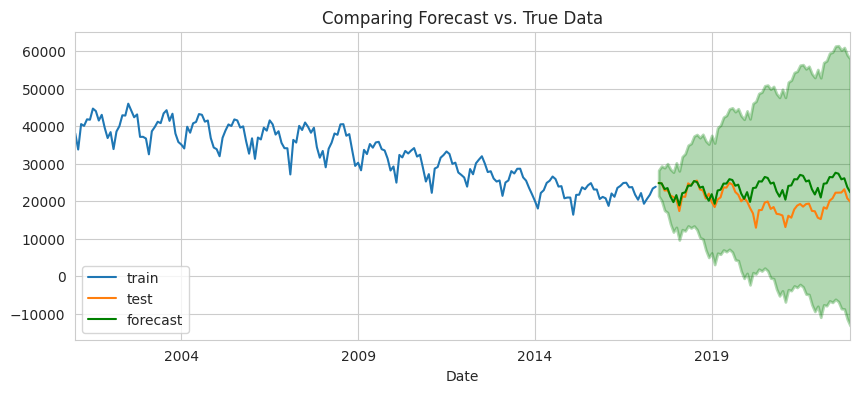

In [205]:
# Use auto_arima parameters to fit an ARIMA
auto_model = tsa.ARIMA(
    train, order=auto_model.order, seasonal_order=auto_model.seasonal_order
).fit()


# Obtain forecast as a dataframe with confidence intervals
forecast_df = auto_model.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

# Results for Total Crime (sum of all crime types).
Model:	ARIMA(1, 1, 0)x(1, 0, [1], 12)
- Regression Metrics:
- MAE = 1,694.991
- MSE = 5,012,026.422
- RMSE = 2,238.756
- R^2 = 0.432
- MAPE = 9.45%
------------------------------------------------------------
Model:	SARIMAX(2, 1, 2)x(2, 0, [1], 12)
-Regression Metrics:
- MAE = 3,791.584
- MSE = 22,980,890.426
- RMSE = 4,793.839
- R^2 = -1.604
- MAPE = 21.11%

**according to these results the ARIMA(1, 1, 0)x(1, 0, [1], 12) model is better**

- Which of the two crimes is forecasted to have the highest monthly count of crimes at the end of the forecast?
  - Total Crime
- Which of the two crimes is forecasted to have the highest net change by the end of the forecast?
  - Theft Crime
- Which of the two crimes is forecasted to have the highest percent change by the end of the forecast?
  - Total Crime